# Copula Selection Heuristics: Finding Optimal Copula Decision Boundaries

## Gaussian Fit

#### Generating Gaussian Data & Calculating Tails

In [66]:
import numpy as np
from scipy.stats import norm
from scipy.stats import t as student_t

data = []

q = 0.1 #tail dependence percentage. bottom and top 10%
n = 1000 #num of r.v. per feature
s = 100 #num of simulations per rho value
for p in np.linspace(0, 0.99, 100):
    for _ in range(s):
        x = np.random.normal(0, 1, n)
        y = p*x + np.sqrt(1-p**2)*np.random.normal(0, 1, n)
        u = norm.cdf(x)  # Transform to uniform via CDF
        v = norm.cdf(y)

        #Calculating Tails
        lower = np.mean((u <= q) & (v <= q)) / q
        upper = np.mean((u > 1-q) & (v > 1-q)) / q

        data.append(('gaussian', lower, upper, p, u, v))

# 2. Clayton data
for theta in np.linspace(0.1, 8, 50):  # Clayton strength parameter
    for _ in range(s):
        u = np.random.uniform(0, 1, n)
        w = np.random.uniform(0, 1, n)
        v = (u**(-theta) * (w**(-theta/(1+theta)) - 1) + 1)**(-1/theta)
        # Transform to normal marginals for consistency
        x = norm.ppf(u)
        y = norm.ppf(v)
        # Calculate correlation for rho
        p = np.corrcoef(x, y)[0, 1]
        lower = np.mean((u <= q) & (v <= q)) / q
        upper = np.mean((u > 1-q) & (v > 1-q)) / q
        data.append(('clayton', lower, upper, p, u, v))  # Added 'clayton'

# 3. Student-t data
for nu in np.linspace(2.1, 30, 50):  # degrees of freedom
    for _ in range(s):
        # Generate bivariate t (simplified)
        rho = 0.7  # Fixed correlation
        cov = [[1, rho], [rho, 1]]
        # Multivariate t generation
        x = np.random.normal(0, 1, n)
        y = rho*x + np.sqrt(1-rho**2)*np.random.normal(0, 1, n)
        # Apply t-distribution scaling
        chi2 = np.random.chisquare(nu, n)
        x_t = x * np.sqrt(nu/chi2)
        y_t = y * np.sqrt(nu/chi2)
        u = student_t.cdf(x_t, df=nu)
        v = student_t.cdf(y_t, df=nu)
        lower = np.mean((u <= q) & (v <= q)) / q
        upper = np.mean((u > 1-q) & (v > 1-q)) / q
        data.append(('student_t', lower, upper, rho, u, v))  # Added 'student_t'

#### Fit All Copulas

In [67]:
import sys
sys.path.append('../src')  # Adjust path as needed
from copula_families import GaussianCopula, StudentTCopula, ClaytonCopula
import pandas as pd

data_points = []

#Format is as follows. (lambda_left, lambda_right, rho, np.array(u, v))
results = {"Gaussian": {"Winner": 0, "lambda_l_max": (-np.inf, None, None, None), "lambda_l_min": (np.inf, None, None, None),
                        "lambda_r_max": (None, -np.inf, None, None), "lambda_r_min": (None, np.inf, None, None),
                        "both_max": (None, None, None, None), "both_min": (None, None, None, None),
                        "r_max_l_min": (None, None, None, None), "r_min_l_max": (None, None, None, None),
                        "rho_max": (None, None, None, None), "rho_min": (None, None, None, None)},

            "Clayton": {"Winner": 0, "lambda_l_max": (-np.inf, None, None, None), "lambda_l_min": (np.inf, None, None, None),
                        "lambda_r_max": (None, -np.inf, None, None), "lambda_r_min": (None, np.inf, None, None),
                        "both_max": (None, None, None, None), "both_min": (None, None, None, None),
                        "r_max_l_min": (None, None, None, None), "r_min_l_max": (None, None, None, None),
                        "rho_max": (None, None, None, None), "rho_min": (None, None, None, None)},

            "Student_T": {"Winner": 0, "lambda_l_max": (-np.inf, None, None, None), "lambda_l_min": (np.inf, None, None, None),
                        "lambda_r_max": (None, -np.inf, None, None), "lambda_r_min": (None, np.inf, None, None),
                        "both_max": (None, None, None, None), "both_min": (None, None, None, None),
                        "r_max_l_min": (None, None, None, None), "r_min_l_max": (None, None, None, None),
                        "rho_max": (None, None, None, None), "rho_min": (None, None, None, None)},

                        }

for d in data:
    data_type, lambda_l, lambda_r, rho, u, v = d

    # Compute Gaussian Copula
    gaussian = GaussianCopula()
    gaussian.fit(u, v)
    aic_gaussian = gaussian.aic(u, v)

    # Compute Clayton Copula
    clayton = ClaytonCopula()
    clayton.fit(u, v)
    aic_clayton = clayton.aic(u, v)

    # Compute Student T Copula
    student_t = StudentTCopula()
    student_t.fit(u, v)
    aic_student_t = student_t.aic(u, v)

    # Which one is better?
    if aic_gaussian <= aic_clayton and aic_gaussian <= aic_student_t:
        results["Gaussian"]["Winner"] += 1
        winner = 'Gaussian'
    elif aic_clayton < aic_gaussian and aic_clayton <= aic_student_t:
        results["Clayton"]["Winner"] += 1
        winner = 'Clayton'
    else:
        results["Student_T"]["Winner"] += 1
        winner = 'Student_T'

    # Create df
    data_points.append({
        'data_type': data_type,
        'lambda_l': lambda_l,
        'lambda_r': lambda_r, 
        'rho': rho,
        'best_copula': winner
    })

    # lambda_l_max
    if lambda_l > results[winner]['lambda_l_max'][0]:
        results[winner]['lambda_l_max'] = lambda_l, lambda_r, rho, u, v

    # lambda_l_min
    if lambda_l < results[winner]['lambda_l_min'][0]:
        results[winner]['lambda_l_min'] = lambda_l, lambda_r, rho, u, v

    # lambda_r_max
    if lambda_r > results[winner]['lambda_r_max'][1]:
        results[winner]['lambda_r_max'] = lambda_l, lambda_r, rho, u, v

    # lambda_r_min
    if lambda_r < results[winner]['lambda_r_min'][1]:
        results[winner]['lambda_r_min'] = lambda_l, lambda_r, rho, u, v

    # both max
    if (results[winner]['both_max'][0] is None or 
                    (lambda_l >= results[winner]['both_max'][0] and lambda_r >= results[winner]['both_max'][1])):
        results[winner]['both_max'] = lambda_l, lambda_r, rho, u, v

    # both min
    if (results[winner]['both_min'][0] is None or 
                    (lambda_l <= results[winner]['both_min'][0] and lambda_r <= results[winner]['both_min'][1])):
        results[winner]['both_min'] = lambda_l, lambda_r, rho, u, v

    # lambda_l min lambda_r max
    if (results[winner]['r_max_l_min'][0] is None or
        (lambda_l <= results[winner]['r_max_l_min'][0] and lambda_r >= results[winner]['r_max_l_min'][1])):
        results[winner]['r_max_l_min'] = lambda_l, lambda_r, rho, u, v

    # lambda_l max lambda_r min
    if (results[winner]['r_min_l_max'][0] is None or
        (lambda_l >= results[winner]['r_min_l_max'][0] and lambda_r <= results[winner]['r_min_l_max'][1])):
        results[winner]['r_min_l_max'] = lambda_l, lambda_r, rho, u, v

    # rho_max
    if (results[winner]['rho_max'][0] is None or
        (rho > results[winner]['rho_max'][2])):
        results[winner]['rho_max'] = lambda_l, lambda_r, rho, u, v

    # rho_min
    if (results[winner]['rho_min'][0] is None or 
        (rho < results[winner]['rho_min'][2])):
        results[winner]['rho_min'] = lambda_l, lambda_r, rho, u, v
    

print("Gaussian Best", results["Gaussian"]["Winner"])
print("Clayton Best", results["Clayton"]["Winner"])
print("Student T Best", results["Student_T"]["Winner"])

df_results = pd.DataFrame(data_points)
#print(df_results)


Gaussian Best 9971
Clayton Best 5291
Student T Best 4738


#### Visualizing Scatterplot

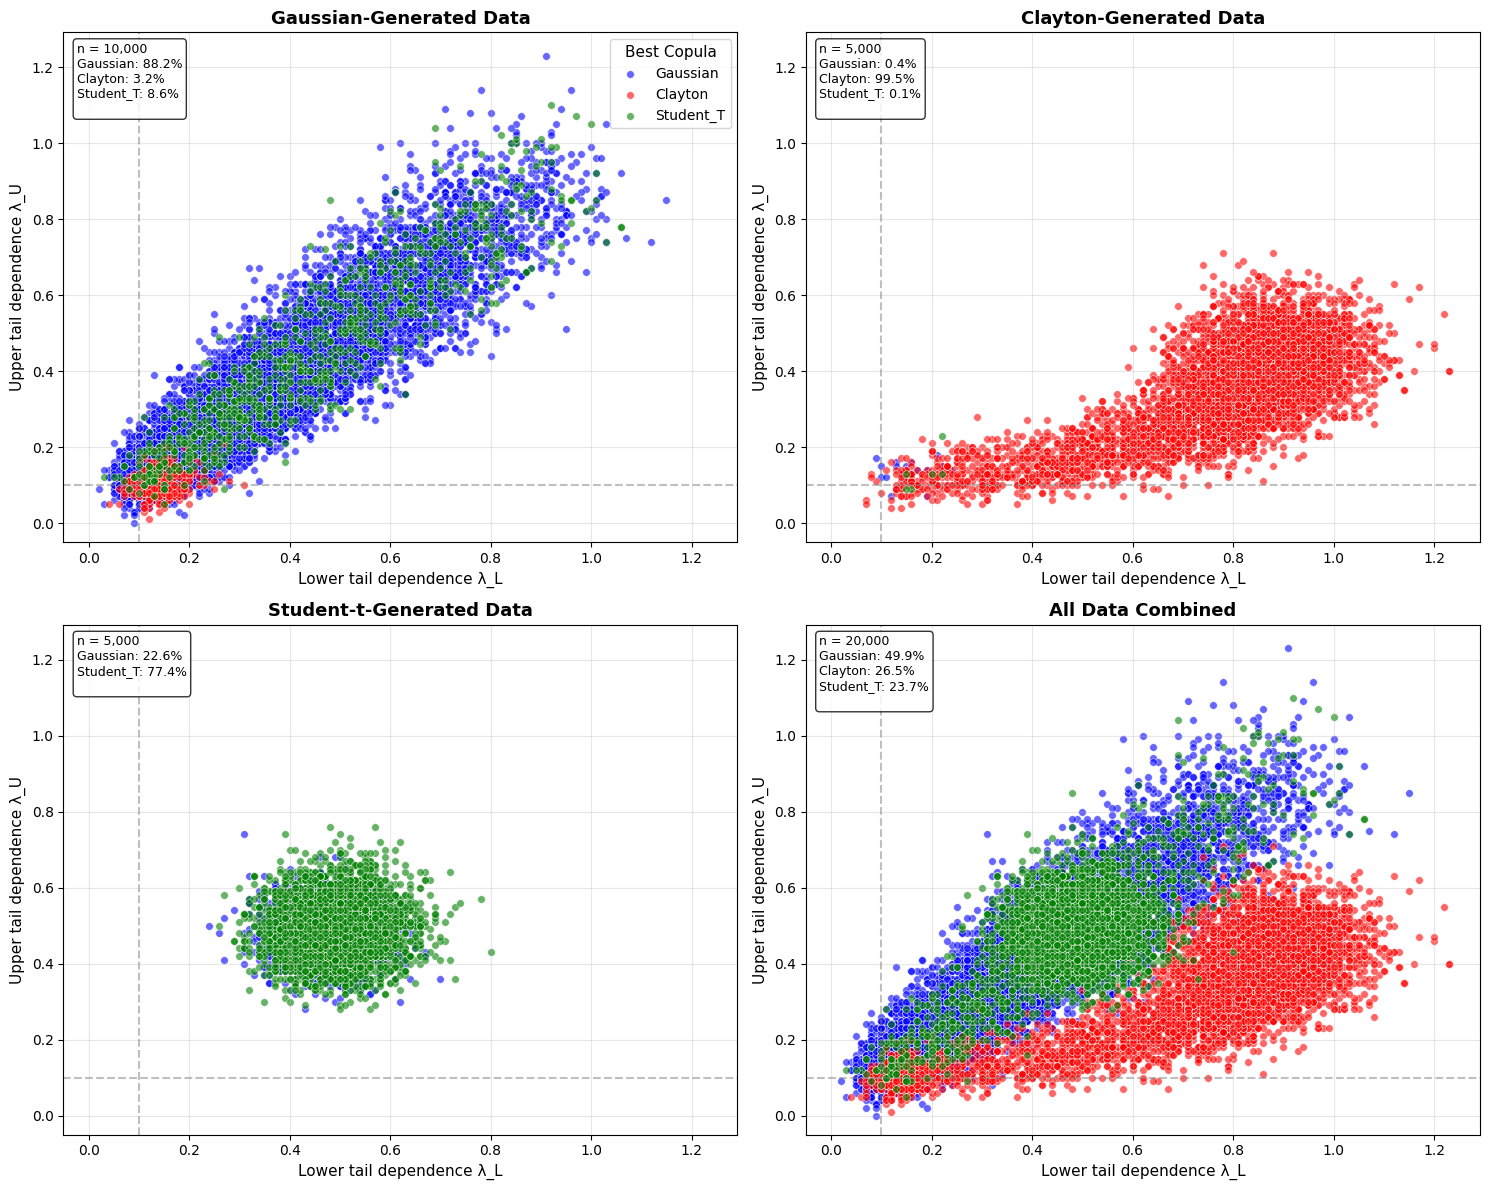

OVERALL STATISTICS BY DATA TYPE

GAUSSIAN-generated data:
  Total samples: 10,000
  Gaussian: 8,818 (88.2%)
  Clayton: 318 (3.2%)
  Student_T: 864 (8.6%)

CLAYTON-generated data:
  Total samples: 5,000
  Gaussian: 21 (0.4%)
  Clayton: 4,973 (99.5%)
  Student_T: 6 (0.1%)

STUDENT_T-generated data:
  Total samples: 5,000
  Gaussian: 1,132 (22.6%)
  Student_T: 3,868 (77.4%)


In [68]:
import matplotlib.pyplot as plt

# Color mapping
color_map = {
    'Gaussian': 'blue',
    'Clayton': 'red', 
    'Student_T': 'green'
}

# Create 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

# Titles for each subplot
titles = [
    'Gaussian-Generated Data',
    'Clayton-Generated Data', 
    'Student-t-Generated Data',
    'All Data Combined'
]

# Filter data for each type
df_gaussian = df_results[df_results['data_type'] == 'gaussian']
df_clayton = df_results[df_results['data_type'] == 'clayton']
df_student = df_results[df_results['data_type'] == 'student_t']

# Data for each subplot
datasets = [df_gaussian, df_clayton, df_student, df_results]

for idx, (ax, title, df) in enumerate(zip(axes, titles, datasets)):
    # Plot each copula type
    for copula, color in color_map.items():
        subset = df[df['best_copula'] == copula]
        if len(subset) > 0:
            ax.scatter(subset['lambda_l'], subset['lambda_r'], 
                      c=color, label=copula, alpha=0.6, s=30, edgecolors='w', linewidth=0.5)
    
    # Add labels and title
    ax.set_xlabel('Lower tail dependence λ_L', fontsize=11)
    ax.set_ylabel('Upper tail dependence λ_U', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add reference lines for independence (0.1)
    ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5)
    
    # Set consistent axis limits for comparison
    ax.set_xlim(-0.05, df_results['lambda_l'].max() * 1.05)
    ax.set_ylim(-0.05, df_results['lambda_r'].max() * 1.05)
    
    # Add legend only to first plot (avoid repetition)
    if idx == 0:
        ax.legend(title='Best Copula', fontsize=10, title_fontsize=11)
    
    # Add statistics text box
    total = len(df)
    if total > 0:
        stats_text = f"n = {total:,}\n"
        for copula in color_map.keys():
            count = len(df[df['best_copula'] == copula])
            if count > 0:
                percentage = 100 * count / total
                stats_text += f"{copula}: {percentage:.1f}%\n"
        
        # Add text box
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print overall statistics
print("="*60)
print("OVERALL STATISTICS BY DATA TYPE")
print("="*60)

for data_type in ['gaussian', 'clayton', 'student_t']:
    df_type = df_results[df_results['data_type'] == data_type]
    print(f"\n{data_type.upper()}-generated data:")
    print(f"  Total samples: {len(df_type):,}")
    for copula in color_map.keys():
        count = len(df_type[df_type['best_copula'] == copula])
        if count > 0:
            percentage = 100 * count / len(df_type)
            print(f"  {copula}: {count:,} ({percentage:.1f}%)")

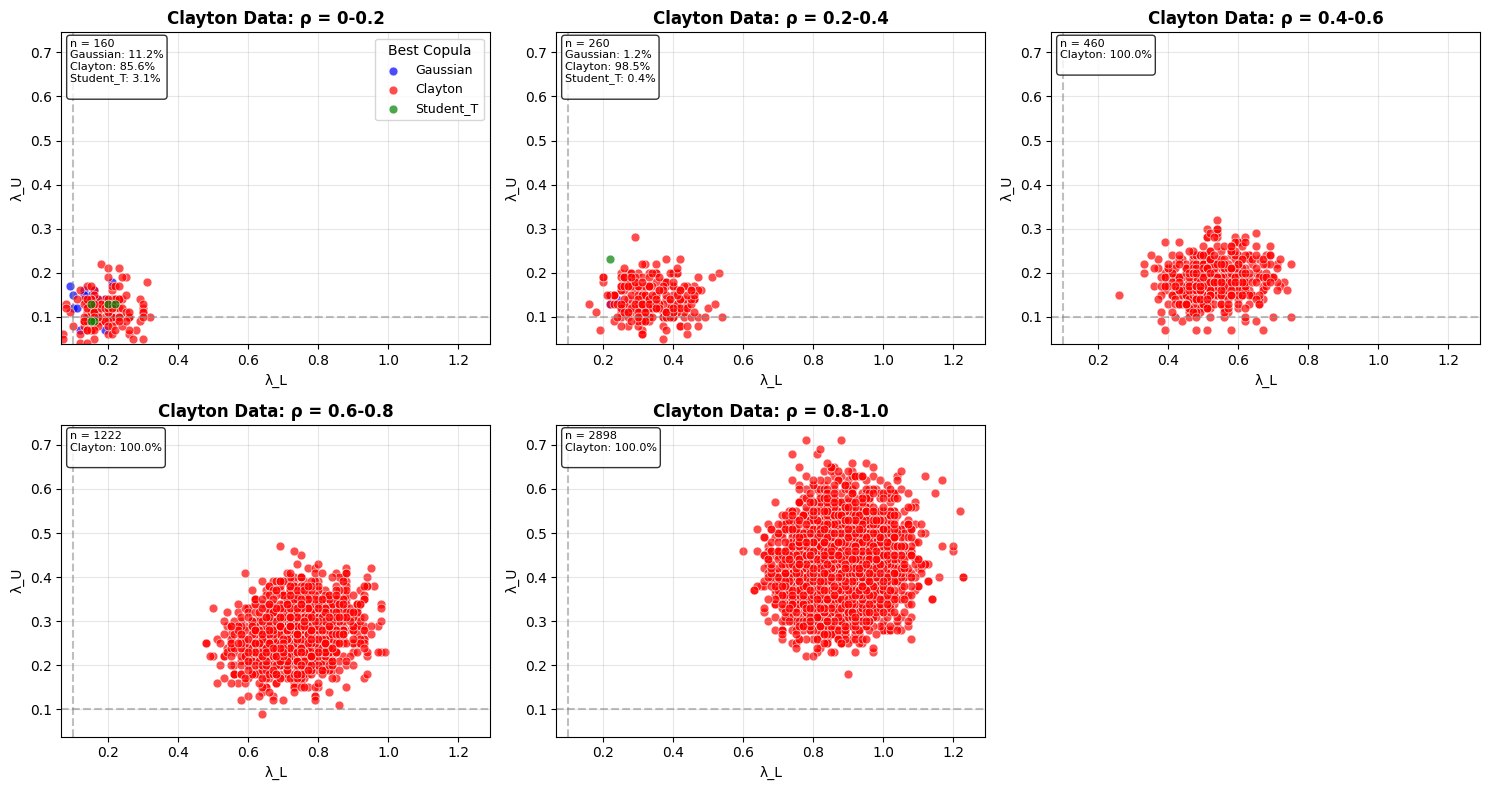

CLAYTON DATA: COPULA WIN RATES BY CORRELATION (ρ) RANGE

ρ = 0-0.2:
  Samples: 160
  λ_L range: [0.070, 0.320]
  λ_U range: [0.040, 0.220]
  Clayton: 137 (85.6%)
  Gaussian: 18 (11.2%)
  Student_T: 5 (3.1%)

ρ = 0.2-0.4:
  Samples: 260
  λ_L range: [0.160, 0.540]
  λ_U range: [0.050, 0.280]
  Clayton: 256 (98.5%)
  Gaussian: 3 (1.2%)
  Student_T: 1 (0.4%)

ρ = 0.4-0.6:
  Samples: 460
  λ_L range: [0.260, 0.750]
  λ_U range: [0.070, 0.320]
  Clayton: 460 (100.0%)

ρ = 0.6-0.8:
  Samples: 1222
  λ_L range: [0.480, 0.990]
  λ_U range: [0.090, 0.470]
  Clayton: 1222 (100.0%)

ρ = 0.8-1.0:
  Samples: 2898
  λ_L range: [0.600, 1.230]
  λ_U range: [0.180, 0.710]
  Clayton: 2898 (100.0%)


In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter Clayton-generated data
df_clayton = df_results[df_results['data_type'] == 'clayton'].copy()

# Create ρ bins (correlation ranges)
df_clayton['rho_bin'] = pd.cut(df_clayton['rho'], 
                               bins=[-1, 0.2, 0.4, 0.6, 0.8, 1.0],
                               labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

# Color mapping
color_map = {
    'Gaussian': 'blue',
    'Clayton': 'red', 
    'Student_T': 'green'
}

# Create figure with subplots for each ρ range
rho_bins = df_clayton['rho_bin'].cat.categories
n_bins = len(rho_bins)
n_cols = 3  # 3 columns per row
n_rows = (n_bins + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

# Plot each ρ bin
for idx, rho_range in enumerate(rho_bins):
    ax = axes[idx]
    df_bin = df_clayton[df_clayton['rho_bin'] == rho_range]
    
    # Plot each copula type
    for copula, color in color_map.items():
        subset = df_bin[df_bin['best_copula'] == copula]
        if len(subset) > 0:
            ax.scatter(subset['lambda_l'], subset['lambda_r'], 
                      c=color, label=copula, alpha=0.7, s=40, edgecolors='w', linewidth=0.5)
    
    # Add labels and title
    ax.set_xlabel('λ_L')
    ax.set_ylabel('λ_U')
    ax.set_title(f'Clayton Data: ρ = {rho_range}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add reference lines
    ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5)
    
    # Set consistent axis limits
    ax.set_xlim(df_clayton['lambda_l'].min() * 0.95, df_clayton['lambda_l'].max() * 1.05)
    ax.set_ylim(df_clayton['lambda_r'].min() * 0.95, df_clayton['lambda_r'].max() * 1.05)
    
    # Add legend to first plot only
    if idx == 0:
        ax.legend(title='Best Copula', fontsize=9)
    
    # Add statistics
    total = len(df_bin)
    if total > 0:
        stats_text = f"n = {total}\n"
        for copula in color_map.keys():
            count = len(df_bin[df_bin['best_copula'] == copula])
            if count > 0:
                percentage = 100 * count / total
                stats_text += f"{copula}: {percentage:.1f}%\n"
        
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide any unused subplots
for idx in range(len(rho_bins), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Print summary statistics by ρ bin
print("="*70)
print("CLAYTON DATA: COPULA WIN RATES BY CORRELATION (ρ) RANGE")
print("="*70)

for rho_range in rho_bins:
    df_bin = df_clayton[df_clayton['rho_bin'] == rho_range]
    if len(df_bin) > 0:
        print(f"\nρ = {rho_range}:")
        print(f"  Samples: {len(df_bin)}")
        print(f"  λ_L range: [{df_bin['lambda_l'].min():.3f}, {df_bin['lambda_l'].max():.3f}]")
        print(f"  λ_U range: [{df_bin['lambda_r'].min():.3f}, {df_bin['lambda_r'].max():.3f}]")
        
        for copula in ['Clayton', 'Gaussian', 'Student_T']:
            count = len(df_bin[df_bin['best_copula'] == copula])
            if count > 0:
                percentage = 100 * count / len(df_bin)
                print(f"  {copula}: {count} ({percentage:.1f}%)")

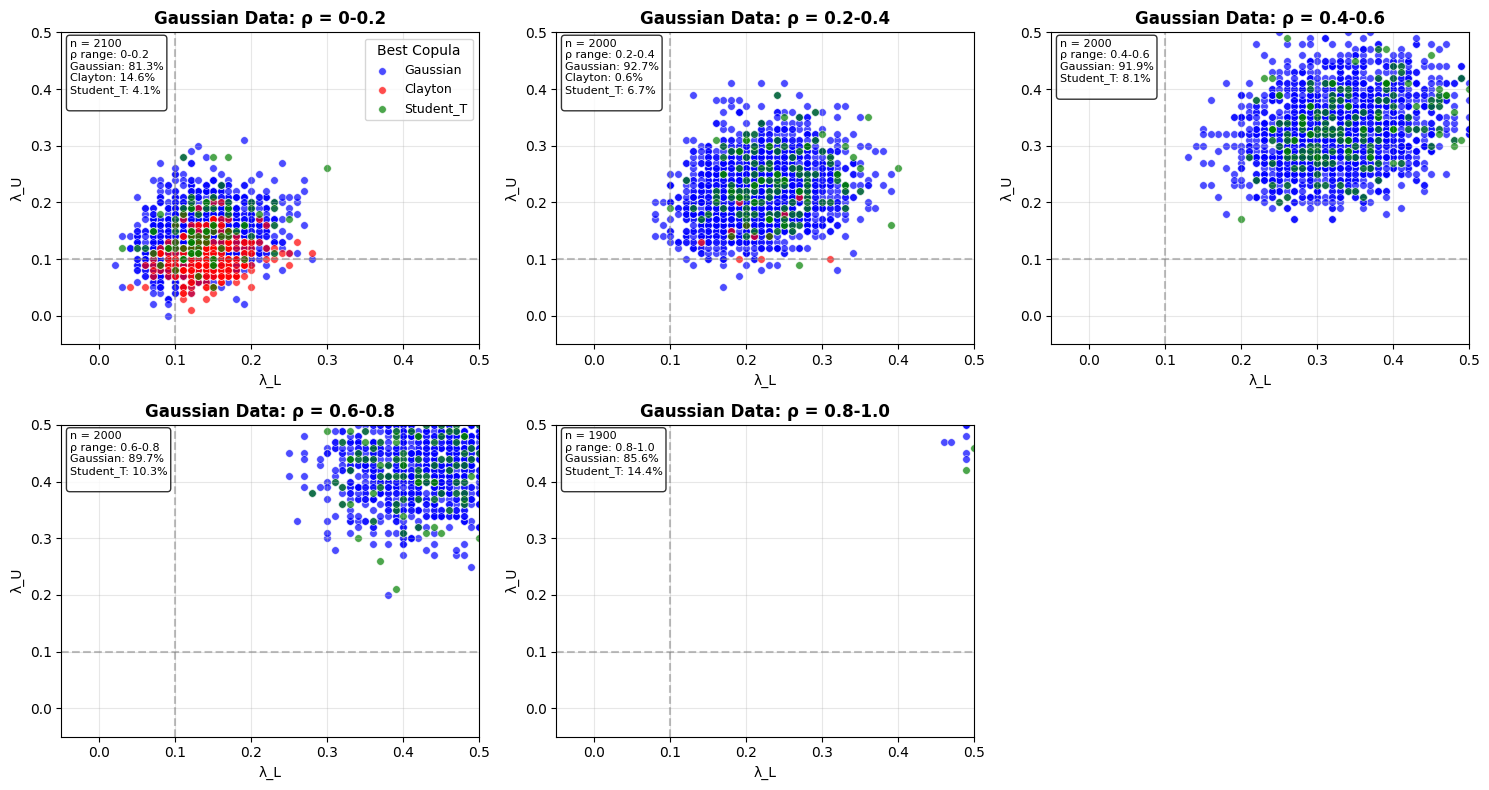

GAUSSIAN DATA: COPULA WIN RATES BY CORRELATION (ρ) RANGE

ρ = 0-0.2:
  Samples: 2100
  Avg λ_L: 0.134 ± 0.041
  Avg λ_U: 0.134 ± 0.043
  Gaussian: 1707 (81.3%)
  Clayton: 306 (14.6%)
  Student_T: 87 (4.1%)

ρ = 0.2-0.4:
  Samples: 2000
  Avg λ_L: 0.219 ± 0.053
  Avg λ_U: 0.218 ± 0.055
  Gaussian: 1854 (92.7%)
  Clayton: 12 (0.6%)
  Student_T: 134 (6.7%)

ρ = 0.4-0.6:
  Samples: 2000
  Avg λ_L: 0.328 ± 0.067
  Avg λ_U: 0.329 ± 0.065
  Gaussian: 1838 (91.9%)
  Student_T: 162 (8.1%)

ρ = 0.6-0.8:
  Samples: 2000
  Avg λ_L: 0.473 ± 0.085
  Avg λ_U: 0.473 ± 0.085
  Gaussian: 1793 (89.7%)
  Student_T: 207 (10.3%)

ρ = 0.8-1.0:
  Samples: 1900
  Avg λ_L: 0.702 ± 0.125
  Avg λ_U: 0.706 ± 0.126
  Gaussian: 1626 (85.6%)
  Student_T: 274 (14.4%)


In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter Gaussian-generated data
df_gaussian = df_results[df_results['data_type'] == 'gaussian'].copy()

# Create ρ bins (correlation ranges)
df_gaussian['rho_bin'] = pd.cut(df_gaussian['rho'], 
                                bins=[-0.05, 0.2, 0.4, 0.6, 0.8, 1.0],
                                labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

# Color mapping
color_map = {
    'Gaussian': 'blue',
    'Clayton': 'red', 
    'Student_T': 'green'
}

# Create figure with subplots for each ρ range
rho_bins = df_gaussian['rho_bin'].cat.categories
n_bins = len(rho_bins)
n_cols = 3  # 3 columns per row
n_rows = (n_bins + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

# Plot each ρ bin
for idx, rho_range in enumerate(rho_bins):
    ax = axes[idx]
    df_bin = df_gaussian[df_gaussian['rho_bin'] == rho_range]
    
    # Plot each copula type
    for copula, color in color_map.items():
        subset = df_bin[df_bin['best_copula'] == copula]
        if len(subset) > 0:
            ax.scatter(subset['lambda_l'], subset['lambda_r'], 
                      c=color, label=copula, alpha=0.7, s=30, edgecolors='w', linewidth=0.5)
    
    # Add labels and title
    ax.set_xlabel('λ_L')
    ax.set_ylabel('λ_U')
    ax.set_title(f'Gaussian Data: ρ = {rho_range}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add reference lines
    ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5)
    
    # Set consistent axis limits (Gaussian should be near 0.1)
    ax.set_xlim(-0.05, 0.5)
    ax.set_ylim(-0.05, 0.5)
    
    # Add legend to first plot only
    if idx == 0:
        ax.legend(title='Best Copula', fontsize=9)
    
    # Add statistics
    total = len(df_bin)
    if total > 0:
        stats_text = f"n = {total}\nρ range: {rho_range}\n"
        for copula in ['Gaussian', 'Clayton', 'Student_T']:
            count = len(df_bin[df_bin['best_copula'] == copula])
            if count > 0:
                percentage = 100 * count / total
                stats_text += f"{copula}: {percentage:.1f}%\n"
        
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide any unused subplots
for idx in range(len(rho_bins), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Print summary statistics by ρ bin
print("="*70)
print("GAUSSIAN DATA: COPULA WIN RATES BY CORRELATION (ρ) RANGE")
print("="*70)

for rho_range in rho_bins:
    df_bin = df_gaussian[df_gaussian['rho_bin'] == rho_range]
    if len(df_bin) > 0:
        print(f"\nρ = {rho_range}:")
        print(f"  Samples: {len(df_bin)}")
        print(f"  Avg λ_L: {df_bin['lambda_l'].mean():.3f} ± {df_bin['lambda_l'].std():.3f}")
        print(f"  Avg λ_U: {df_bin['lambda_r'].mean():.3f} ± {df_bin['lambda_r'].std():.3f}")
        
        for copula in ['Gaussian', 'Clayton', 'Student_T']:
            count = len(df_bin[df_bin['best_copula'] == copula])
            if count > 0:
                percentage = 100 * count / len(df_bin)
                print(f"  {copula}: {count} ({percentage:.1f}%)")

In [71]:
# # Create ρ bins
# df_results['rho_bin'] = pd.cut(df_results['rho'], 
#                                bins=[0, 0.3, 0.6, 0.9, 1.0],
#                                labels=['0-0.3', '0.3-0.6', '0.6-0.9', '0.9-1.0'])

# # Plot 2x2 grid
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()

# for idx, (rho_range, ax) in enumerate(zip(df_results['rho_bin'].cat.categories, axes)):
#     subset = df_results[df_results['rho_bin'] == rho_range]
    
#     for copula, color in color_map.items():
#         copula_subset = subset[subset['best_copula'] == copula]
#         ax.scatter(copula_subset['lambda_l'], copula_subset['lambda_r'],
#                    c=color, label=copula, alpha=0.7, s=40)
    
#     ax.set_xlabel('λ_L')
#     ax.set_ylabel('λ_U')
#     ax.set_title(f'ρ = {rho_range}')
#     ax.grid(True, alpha=0.3)
    
#     if idx == 0:
#         ax.legend(title='Best Copula')

# plt.tight_layout()
# plt.show()

In [72]:
# fig, ax = plt.subplots(figsize=(10, 8))

# # Use colormap for ρ
# scatter = ax.scatter(df_results['lambda_l'], df_results['lambda_r'],
#                      c=df_results['rho'], cmap='viridis', 
#                      alpha=0.7, s=50)

# # Add colorbar for ρ
# plt.colorbar(scatter, label='ρ (correlation)')

# # Add labels
# ax.set_xlabel('λ_L')
# ax.set_ylabel('λ_U')
# ax.set_title('Tail Dependence with Correlation Heatmap')
# ax.grid(True, alpha=0.3)

# # Optional: Overlay copula type with markers
# for copula, marker in [('Gaussian', 'o'), ('Clayton', 's'), ('Student_T', '^')]:
#     subset = df_results[df_results['best_copula'] == copula]
#     if len(subset) > 0:
#         ax.scatter(subset['lambda_l'], subset['lambda_r'],
#                    facecolors='none', edgecolors='black',
#                    marker=marker, s=100, label=copula)

# plt.legend()
# plt.show()

In [73]:
# from mpl_toolkits.mplot3d import Axes3D

# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection='3d')

# for copula, color in color_map.items():
#     subset = df_results[df_results['best_copula'] == copula]
#     ax.scatter(subset['lambda_l'], subset['lambda_r'], subset['rho'],
#                c=color, label=copula, alpha=0.6, s=30)

# ax.set_xlabel('λ_L')
# ax.set_ylabel('λ_U')  
# ax.set_zlabel('ρ (correlation)')
# ax.set_title('Copula Selection: λ_L vs λ_U vs ρ')
# plt.legend()
# plt.show()